# Credit Risk Modeling - Take-Home Assignment


---

## Objective

Build a production-ready modeling workflow to predict the probability of 12-month loan default.

---

## Table of Contents

1. [Setup & Data Loading](#1-setup--data-loading)
2. [Exploratory Data Analysis (EDA)](#2-exploratory-data-analysis-eda)
3. [Data Preprocessing & Feature Engineering](#3-data-preprocessing--feature-engineering)
4. [Model Training](#4-model-training)
5. [Model Evaluation & Comparison](#5-model-evaluation--comparison)
6. [Model Interpretation](#6-model-interpretation)
7. [Discussion & Next Steps](#7-discussion--next-steps)

---


## 1. Setup & Data Loading


In [53]:
# !pip install optuna
# !pip install lightgbm

In [76]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.calibration import calibration_curve 
from sklearn.metrics import (
    roc_auc_score, 
    roc_curve, 
    average_precision_score,
    brier_score_loss,
    precision_recall_curve,
    classification_report,
    confusion_matrix
)

#import lightgbm as lgb
import xgboost as xgb
#import optuna
import shap
import warnings

import warnings
warnings.filterwarnings('ignore')


RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

TRAIN_END  = 202209
CAL_START  = 202210
CAL_END    = 202212
TEST_START = 202401

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['figure.dpi'] = 100

In [ ]:
# Load data
df = pd.read_csv('../data/credit_risk_data_enhanced.csv')

print(f"Dataset shape: {df.shape}")
print(f'Vintage range: {df["vintage"].min()} → {df["vintage"].max()}')
print(f'Default rate:  {df["default_12m"].mean():.2%}')
print(f'Columns:\n  {list(df.columns)}')
df.head()


Dataset shape: (50000, 22)
Vintage range: 202101 → 202409
Default rate:  2.85%
Columns:
  ['loan_id', 'origination_date', 'vintage', 'months_on_book', 'fico_score', 'income', 'debt_to_income', 'num_open_trades', 'utilization_rate', 'inquiries_last_6m', 'loan_amount', 'term', 'apr', 'channel', 'product_type', 'employment_length', 'state', 'age', 'days_past_due_current', 'total_payments_to_date', 'sample_weight', 'default_12m']


,loan_id,origination_date,vintage,months_on_book,fico_score,income,debt_to_income,num_open_trades,utilization_rate,inquiries_last_6m,...,apr,channel,product_type,employment_length,state,age,days_past_due_current,total_payments_to_date,sample_weight,default_12m
0,LOAN_000000,2024-03-01,202403,6,738,81758,0.0770,7,0.2484,0,...,7.02,Direct,Personal,28,Other,35,15,26162.66,1.0679,0
1,LOAN_000001,2023-05-01,202305,23,818,21891,0.6960,8,0.5129,99,...,11.90,Direct,Auto,5,IL,35,0,41235.13,1.0211,0
2,LOAN_000002,2022-03-01,202203,1,800,82072,0.1439,10,0.5875,1,...,14.01,Partner,Home_Improvement,9,Other,73,0,16494.83,0.8348,0
3,LOAN_000003,2024-07-01,202407,0,657,40335,0.1670,8,0.2927,1,...,10.88,Direct,Debt_Consolidation,14,Other,22,0,23241.67,1.0255,0
4,LOAN_000004,2021-08-01,202108,9,771,11733,0.0337,3,0.1871,0,...,18.10,Partner,Personal,36,NY,54,0,44836.86,1.0370,0


## 2. Exploratory Data Analysis (EDA)

### 2.1 Basic Data Overview


In [36]:

df.info()
print()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   loan_id                 50000 non-null  object 
 1   origination_date        50000 non-null  object 
 2   vintage                 50000 non-null  int64  
 3   months_on_book          50000 non-null  int64  
 4   fico_score              50000 non-null  int64  
 5   income                  50000 non-null  int64  
 6   debt_to_income          50000 non-null  float64
 7   num_open_trades         50000 non-null  int64  
 8   utilization_rate        50000 non-null  float64
 9   inquiries_last_6m       50000 non-null  int64  
 10  loan_amount             50000 non-null  int64  
 11  term                    50000 non-null  int64  
 12  apr                     50000 non-null  float64
 13  channel                 50000 non-null  object 
 14  product_type            50000 non-null

,vintage,months_on_book,fico_score,income,debt_to_income,num_open_trades,utilization_rate,inquiries_last_6m,loan_amount,term,apr,employment_length,age,days_past_due_current,total_payments_to_date,sample_weight,default_12m
count,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,202246.232260,12.021320,5665.02552,56864.588960,0.400049,7.997400,0.499390,3.943820,25581.600380,43.121280,12.333497,19.55368,47.541060,5.059500,18738.261717,1.057634,0.028520
std,107.658671,7.235907,21642.07964,38953.183462,0.200280,2.823167,0.223869,13.651883,14113.520733,10.963599,6.408645,11.53573,15.528408,14.494901,11545.596050,0.357885,0.166455
min,202101.000000,0.000000,550.00000,-1.000000,0.010000,0.000000,0.001900,0.000000,1000.000000,36.000000,3.000000,0.00000,21.000000,0.000000,0.880000,0.800000,0.000000
25%,202112.000000,6.000000,629.00000,31399.750000,0.242175,6.000000,0.326200,1.000000,13335.750000,36.000000,7.280000,10.00000,34.000000,0.000000,8865.465000,0.903700,0.000000
50%,202211.000000,12.000000,708.00000,47925.000000,0.385500,8.000000,0.500100,2.000000,25692.000000,36.000000,12.020000,20.00000,48.000000,0.000000,17953.470000,1.006400,0.000000
75%,202310.000000,18.000000,787.00000,72374.250000,0.544100,10.000000,0.672500,3.000000,37770.250000,60.000000,16.730000,30.00000,61.000000,0.000000,27147.627500,1.108500,0.000000
max,202409.000000,24.000000,99999.00000,535593.000000,0.974700,21.000000,0.999100,99.000000,49998.000000,60.000000,35.990000,39.00000,74.000000,120.000000,49878.640000,3.599400,1.000000


In [ ]:
print('Sentinel / Encoded Missing Values')
print("")
sentinels = {'fico_score': 99999, 'income': -1, 'inquiries_last_6m': 99}
for col, val in sentinels.items():
    n = (df[col] == val).sum()
    print(f'  {col} == {val}: {n:,} ({n/len(df):.1%})')

print("")
print('Observation Window')
print("")
insuf = (df['months_on_book'] < 12).sum()
print(f'  months_on_book < 12: {insuf:,} ({insuf/len(df):.1%}) (right-censored labels)')
print(f'  months_on_book range: {df["months_on_book"].min()} – {df["months_on_book"].max()}')

print("")
print('Leakage Features (post-origination, should remove this)')
print("")
print(f'days_past_due_current  >0: {(df["days_past_due_current"]>0).sum():,} records')
print(f'Corr(DPD>0, default): {(df["days_past_due_current"]>0).astype(int).corr(df["default_12m"]):.3f}')
print(f'Corr(total_payments, default): {df["total_payments_to_date"].corr(df["default_12m"]):.3f}')

Sentinel / Encoded Missing Values

  fico_score == 99999: 2,500 (5.0%)
  income == -1: 1,500 (3.0%)
  inquiries_last_6m == 99: 1,000 (2.0%)

Observation Window

  months_on_book < 12: 24,014 (48.0%) — right-censored labels
  months_on_book range: 0 – 24

Leakage Features (post-origination, should remove this)

  days_past_due_current  >0: 11,195 records
  Corr(DPD>0, default):       0.319
  Corr(total_payments, default): -0.221


Default Rate: 2.85%

Class Distribution:
default_12m
0    48574
1     1426
Name: count, dtype: int64


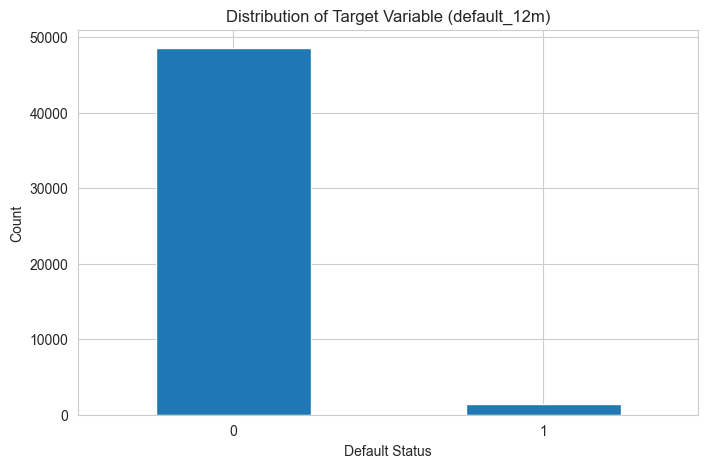

In [38]:
# Target variable distribution
print(f"Default Rate: {df['default_12m'].mean():.2%}")
print(f"\nClass Distribution:")
print(df['default_12m'].value_counts())

# Visualize
plt.figure(figsize=(8, 5))
df['default_12m'].value_counts().plot(kind='bar')
plt.title('Distribution of Target Variable (default_12m)')
plt.xlabel('Default Status')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()


### 2.2 Feature Analysis

TODO: Add your EDA analysis here:
- Distribution plots for numerical features
- Correlation analysis
- Outlier detection
- Relationship between features and target variable
- Analysis of categorical variables


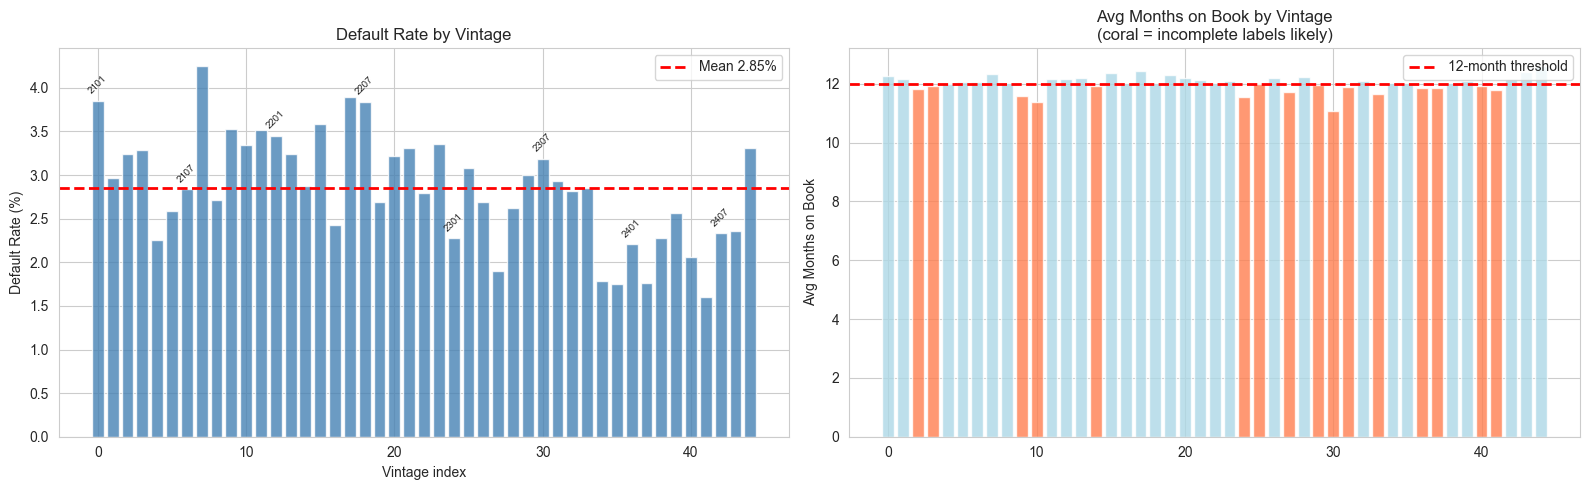

Default rate range (across vintages: 1.60% – 4.25%


In [39]:
vs = df.groupby('vintage').agg(
    n=('default_12m','size'),
    dr=('default_12m','mean'),
    mob=('months_on_book','mean')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(range(len(vs)), vs['dr']*100, color='steelblue', alpha=0.8)
axes[0].axhline(df['default_12m'].mean()*100, color='red', ls='--', lw=2,
                label=f'Mean {df["default_12m"].mean():.2%}')
axes[0].set_title('Default Rate by Vintage')
axes[0].set_ylabel('Default Rate (%)')
axes[0].set_xlabel('Vintage index')
axes[0].legend()
for i in range(0, len(vs), 6):
    axes[0].text(i, vs['dr'].iloc[i]*100+0.08, str(vs['vintage'].iloc[i])[-4:],
                 ha='center', fontsize=7, rotation=45)

clrs = ['coral' if v < 12 else 'lightblue' for v in vs['mob']]
axes[1].bar(range(len(vs)), vs['mob'], color=clrs, alpha=0.8)
axes[1].axhline(12, color='red', ls='--', lw=2, label='12-month threshold')
axes[1].set_title('Avg Months on Book by Vintage\n(coral = incomplete labels likely)')
axes[1].set_ylabel('Avg Months on Book')
axes[1].legend()

plt.tight_layout()
plt.show()
print(f'Default rate range (across vintages: {vs["dr"].min():.2%} – {vs["dr"].max():.2%}')

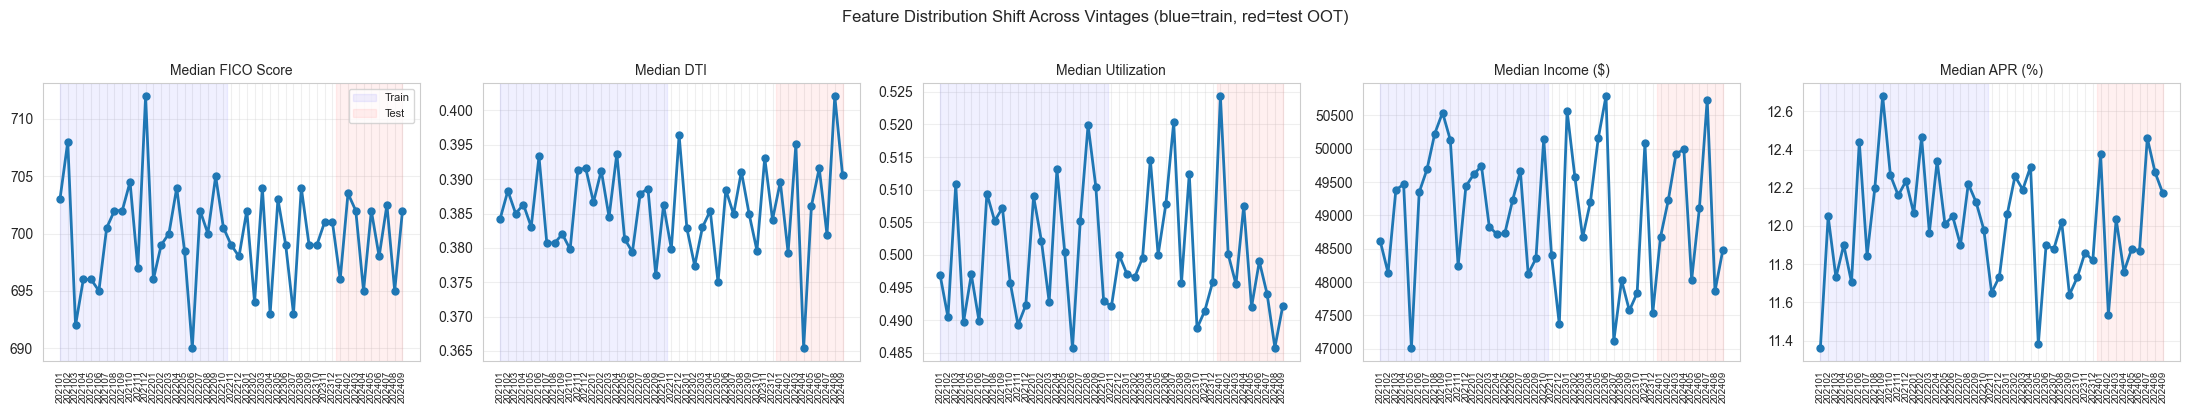

Feature median shift: Train (≤202209) vs OOT Test (≥202401)
Feature                  Train median   Test median          Δ
--------------------------------------------------------------
fico_score                     700.12        699.56      -0.56
debt_to_income                   0.39          0.39      +0.00
utilization_rate                 0.50          0.50      -0.00
income                       49106.60      49116.11      +9.52
apr                             12.08         12.04      -0.04

Delta = >5% relative shift from training distribution — monitor in production


In [ ]:
df_shift = df.copy()
df_shift['fico_score'] = df_shift['fico_score'].replace(99999, np.nan)
df_shift['income'] = df_shift['income'].replace(-1, np.nan)
df_shift['inquiries_last_6m'] = df_shift['inquiries_last_6m'].replace(99, np.nan)

shift_feats = ['fico_score', 'debt_to_income', 'utilization_rate', 'income', 'apr']
shift_df = df_shift.groupby('vintage')[shift_feats].median().reset_index()

fig, axes = plt.subplots(1, len(shift_feats), figsize=(22, 4))
titles = ['Median FICO Score', 'Median DTI', 'Median Utilization', 'Median Income ($)', 'Median APR (%)']
for ax, feat, title in zip(axes, shift_feats, titles):
    ax.plot(shift_df['vintage'].astype(str), shift_df[feat], 'o-', lw=2, ms=5)
    ax.axvspan(0, list(shift_df['vintage'].astype(str)).index('202210')+0.5,
               alpha=0.06, color='blue', label='Train')
    ax.axvspan(list(shift_df['vintage'].astype(str)).index('202401')-0.5,
               len(shift_df)-1, alpha=0.06, color='red', label='Test')
    ax.set_title(title, fontsize=10)
    ax.tick_params(axis='x', rotation=90, labelsize=7)
    ax.grid(alpha=0.3)
    if feat == 'fico_score':
        ax.legend(fontsize=8)

plt.suptitle('Feature Distribution Shift Across Vintages (blue=train, red=test OOT)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

train_vint = shift_df[shift_df['vintage'] <= 202209]
test_vint  = shift_df[shift_df['vintage'] >= 202401]
print('Feature median shift: Train (≤202209) vs OOT Test (≥202401)')
print(f'{"Feature":<22} {"Train median":>14} {"Test median":>13} {"Delta":>10}')
print('-' * 62)
for feat in shift_feats:
    tr_med = train_vint[feat].mean()
    te_med = test_vint[feat].mean()
    delta  = te_med - tr_med
    flag   = 'Delta' if abs(delta/tr_med) > 0.05 else ''
    print(f'{feat:<22} {tr_med:>14.2f} {te_med:>13.2f} {delta:>+10.2f}{flag}')
print('\nDelta = >5% relative shift from training distribution — monitor in production')

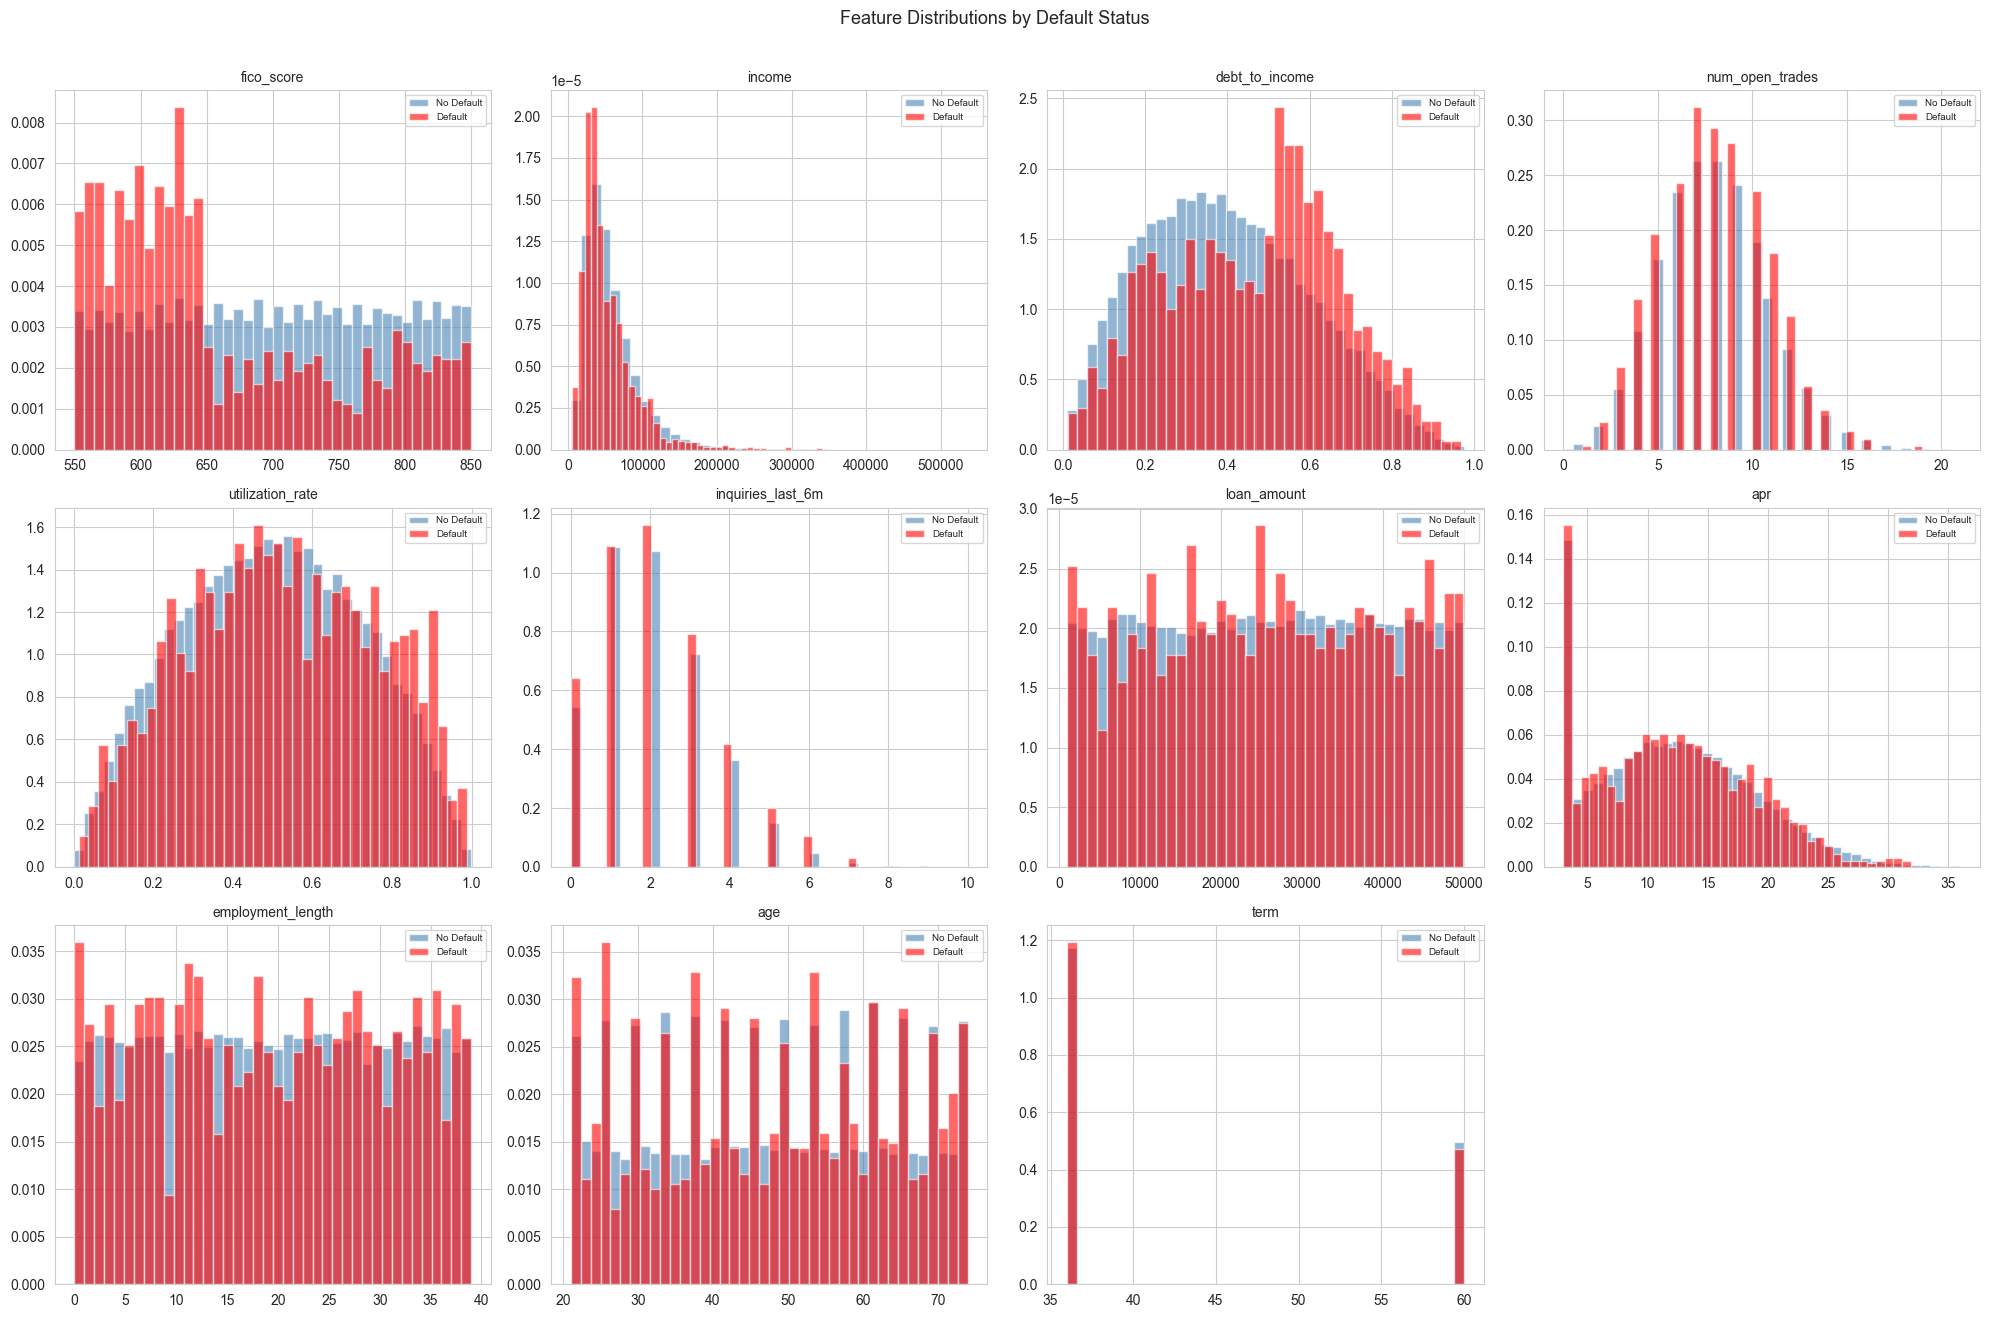

In [ ]:
df_viz = df.copy()
df_viz['fico_score'] = df_viz['fico_score'].replace(99999, np.nan)
df_viz['income'] = df_viz['income'].replace(-1, np.nan)
df_viz['inquiries_last_6m'] = df_viz['inquiries_last_6m'].replace(99, np.nan)

numeric_feats = ['fico_score','income','debt_to_income','num_open_trades',
                 'utilization_rate','inquiries_last_6m','loan_amount',
                 'apr','employment_length','age','term']

fig, axes = plt.subplots(3, 4, figsize=(20, 13))
for i, col in enumerate(numeric_feats):
    ax = axes.flat[i]
    ax.hist(df_viz[df_viz['default_12m']==0][col].dropna(), bins=40,
            alpha=0.6, color='steelblue', label='No Default', density=True)
    ax.hist(df_viz[df_viz['default_12m']==1][col].dropna(), bins=40,
            alpha=0.6, color='red',       label='Default',    density=True)
    ax.set_title(col, fontsize=10)
    ax.legend(fontsize=7)
for j in range(len(numeric_feats), len(axes.flat)):
    axes.flat[j].set_visible(False)
plt.suptitle('Feature Distributions by Default Status', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

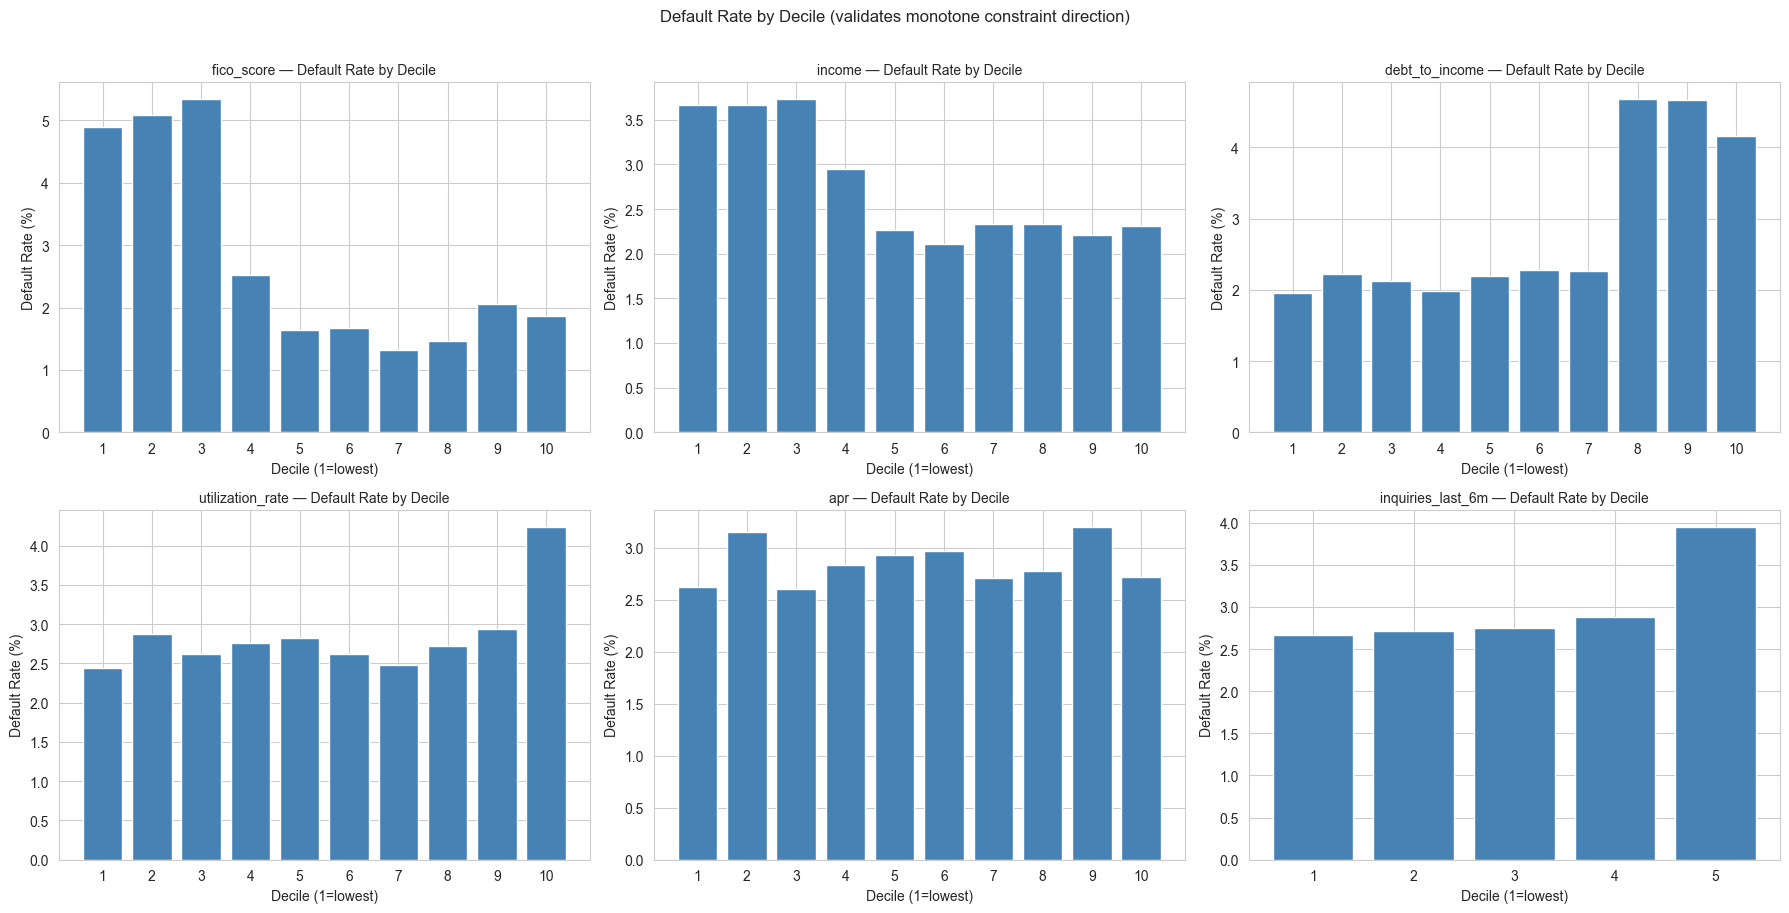

In [42]:
key_feats = ['fico_score','income','debt_to_income','utilization_rate','apr','inquiries_last_6m']
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for i, col in enumerate(key_feats):
    tmp = df_viz[[col, 'default_12m']].dropna()
    try:
        tmp = tmp.copy()
        tmp['bin'] = pd.qcut(tmp[col], q=10, duplicates='drop')
    except Exception:
        tmp['bin'] = pd.cut(tmp[col], bins=10)
    bstats = tmp.groupby('bin', observed=True)['default_12m'].mean() * 100
    axes.flat[i].bar(range(len(bstats)), bstats.values, color='steelblue')
    axes.flat[i].set_title(f'{col} — Default Rate by Decile', fontsize=10)
    axes.flat[i].set_xlabel('Decile (1=lowest)')
    axes.flat[i].set_ylabel('Default Rate (%)')
    axes.flat[i].set_xticks(range(len(bstats)))
    axes.flat[i].set_xticklabels([str(k+1) for k in range(len(bstats))])
plt.suptitle('Default Rate by Decile (validates monotone constraint direction)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

In [43]:

corr_cols = ['fico_score','income','debt_to_income','num_open_trades',
             'utilization_rate','inquiries_last_6m','loan_amount','term',
             'apr','employment_length','age','default_12m']
print('Correlations with default_12m (sorted by |r|):')
corr = df_viz[corr_cols].corr()['default_12m'].drop('default_12m')
print(corr.sort_values(key=abs, ascending=False).round(3).to_string())

Correlations with default_12m (sorted by |r|):
fico_score          -0.076
debt_to_income       0.053
income              -0.023
utilization_rate     0.018
inquiries_last_6m    0.012
term                -0.005
loan_amount          0.003
employment_length   -0.003
age                  0.002
apr                  0.001
num_open_trades      0.001


## 3. Data Preprocessing & Feature Engineering

### 3.1 Handle Missing Values


In [44]:
df_proc = df.copy()


df_proc['fico_score'] = df_proc['fico_score'].replace(99999, np.nan)
df_proc['income'] = df_proc['income'].replace(-1, np.nan)
df_proc['inquiries_last_6m'] = df_proc['inquiries_last_6m'].replace(99, np.nan)


for col in ['fico_score', 'income', 'inquiries_last_6m']:
    df_proc[f'{col}_missing'] = df_proc[col].isna().astype(int)
    dr_m  = df_proc[df_proc[f'{col}_missing']==1]['default_12m'].mean()
    dr_nm = df_proc[df_proc[f'{col}_missing']==0]['default_12m'].mean()
    print(f'{col}_missing  →  default when missing={dr_m:.2%}  vs not missing={dr_nm:.2%}')

LEAKAGE_COLS = ['days_past_due_current', 'total_payments_to_date', 'months_on_book']
df_proc = df_proc.drop(columns=LEAKAGE_COLS)
print(f'\nRemoved leakage columns: {LEAKAGE_COLS}')
print(f'Shape after leakage removal: {df_proc.shape}')

fico_score_missing  →  default when missing=4.16%  vs not missing=2.78%
income_missing  →  default when missing=5.93%  vs not missing=2.76%
inquiries_last_6m_missing  →  default when missing=6.10%  vs not missing=2.79%

Removed leakage columns: ['days_past_due_current', 'total_payments_to_date', 'months_on_book']
Shape after leakage removal: (50000, 22)


### 3.2 Handle Outliers


In [45]:
_income_fill = df_proc['income'].median()
df_proc['loan_to_income'] = df_proc['loan_amount'] / (df_proc['income'].fillna(_income_fill) + 1)
df_proc['monthly_payment_burden'] = (
    (df_proc['loan_amount'] / df_proc['term']) /
    (df_proc['income'].fillna(_income_fill) / 12 + 1)
)

# FICO risk tier (based on google)
df_proc['fico_tier'] = pd.cut(
    df_proc['fico_score'].fillna(650),
    bins=[0, 580, 620, 670, 720, 780, 900],
    labels=[0, 1, 2, 3, 4, 5]  # 0=deep subprime → 5=superprime
).astype(float)

df_proc['high_utilization'] = (df_proc['utilization_rate'] > 0.8).astype(int)
df_proc['high_inquiries'] = (df_proc['inquiries_last_6m'].fillna(0) >= 5).astype(int)
df_proc['high_apr'] = (df_proc['apr'] > 25).astype(int)


le = LabelEncoder()
for col in ['channel', 'product_type', 'state']:
    df_proc[f'{col}_enc'] = le.fit_transform(df_proc[col].fillna('Unknown'))


### 3.3 Feature Engineering


In [46]:

FEATURE_COLS = [
    'fico_score',
    'income',
    'debt_to_income',
    'num_open_trades',
    'utilization_rate',
    'inquiries_last_6m',
    'loan_amount',
    'term',
    'apr',
    'employment_length',
    'age',
    'fico_score_missing',
    'income_missing',
    'inquiries_last_6m_missing',
    'loan_to_income',
    'monthly_payment_burden',
    'fico_tier',
    'high_utilization',
    'high_inquiries',
    'high_apr',
    'channel_enc',
    'product_type_enc',
    'state_enc',
]

MONOTONE = {
    'fico_score': -1,
    'income': -1,
    'debt_to_income': +1,
    'num_open_trades': 0,
    'utilization_rate': +1,
    'inquiries_last_6m': +1,
    'loan_amount': 0,
    'term': +1,
    'apr': +1,
    'employment_length': -1,
    'age': 0,
    'fico_score_missing': +1,
    'income_missing': +1,
    'inquiries_last_6m_missing':+1,
    'loan_to_income': +1,
    'monthly_payment_burden':   +1,
    'fico_tier': -1,
    'high_utilization': +1,
    'high_inquiries': +1,
    'high_apr': +1,
    'channel_enc': 0,
    'product_type_enc':0,
    'state_enc': 0,
}


MONOTONE_LIST = [MONOTONE[f] for f in FEATURE_COLS]
print(f'Feature count: {len(FEATURE_COLS)}')
print(f'Constrained features: {sum(v != 0 for v in MONOTONE_LIST)} / {len(MONOTONE_LIST)}')

Feature count: 23
Constrained features: 17 / 23


In [47]:
# Three-way vintage split
# Base train 202101–202209
# Cal 202210–202212
# OOT 202401–09 (Eval) - Not a full year?
# Gap (202301–202312) is intentionally excluded (no distributional bleed)

TARGET = 'default_12m'
WEIGHT_COL = 'sample_weight'

df_base = df_proc[df_proc['vintage'] <= TRAIN_END].copy()
df_cal = df_proc[(df_proc['vintage'] >= CAL_START) & (df_proc['vintage'] <= CAL_END)].copy()
df_test = df_proc[df_proc['vintage'] >= TEST_START].copy()

print(f'Base train: {len(df_base):,}  vintages {df_base["vintage"].min()}–{df_base["vintage"].max()}  '
      f'default rate={df_base[TARGET].mean():.2%}')
print(f'Calibration:{len(df_cal):,}  vintages {df_cal["vintage"].min()}–{df_cal["vintage"].max()}  '
      f'default rate={df_cal[TARGET].mean():.2%}')
print(f'Test (OOT): {len(df_test):,}  vintages {df_test["vintage"].min()}–{df_test["vintage"].max()}  '
      f'default rate={df_test[TARGET].mean():.2%}')
gap = len(df_proc) - len(df_base) - len(df_cal) - len(df_test)
print(f'Gap excluded (202301–202312): {gap:,} records')
print('\nNOTE: 2024 OOT default labels may be right-censored (<12 months observed).')

Base train: 23,351  vintages 202101–202209  default rate=3.22%
Calibration:3,404  vintages 202210–202212  default rate=3.14%
Test (OOT): 9,984  vintages 202401–202409  default rate=2.27%
Gap excluded (202301–202312): 13,261 records

NOTE: 2024 OOT default labels may be right-censored (<12 months observed).


In [48]:
numeric_fill = ['fico_score','income','debt_to_income','num_open_trades',
                'utilization_rate','inquiries_last_6m','loan_amount','term',
                'apr','employment_length','age',
                'loan_to_income','monthly_payment_burden','fico_tier']

train_medians = df_base[FEATURE_COLS].median()

X_base = df_base[FEATURE_COLS].fillna(train_medians)
X_cal = df_cal[FEATURE_COLS].fillna(train_medians)
X_test = df_test[FEATURE_COLS].fillna(train_medians)

y_base = df_base[TARGET].values
y_cal = df_cal[TARGET].values
y_test = df_test[TARGET].values
w_base = df_base[WEIGHT_COL].values

print(f'X_base: {X_base.shape}  NaN={X_base.isna().sum().sum()}')
print(f'X_cal:  {X_cal.shape}   NaN={X_cal.isna().sum().sum()}')
print(f'X_test: {X_test.shape}  NaN={X_test.isna().sum().sum()}')

X_base: (23351, 23)  NaN=0
X_cal:  (3404, 23)   NaN=0
X_test: (9984, 23)  NaN=0


## 4. Model Training

### 4.1 Model 1: Logistic Regression


In [ ]:
from sklearn.model_selection import BaseCrossValidator

class VintageTimeSeriesSplit(BaseCrossValidator):
    def __init__(self, n_splits=3):
        self.n_splits = n_splits

    def split(self, X, y=None, groups=None):
        unique_vtg = np.sort(np.unique(groups))
        n = len(unique_vtg)
        fold_size = n // (self.n_splits + 1)
        for i in range(1, self.n_splits + 1):
            tr_vtg  = unique_vtg[:fold_size * i]
            val_vtg = unique_vtg[fold_size * i : fold_size * (i + 1)]
            if len(val_vtg) == 0:
                continue
            tr_idx  = np.where(np.isin(groups, tr_vtg))[0]
            val_idx = np.where(np.isin(groups, val_vtg))[0]
            yield tr_idx, val_idx

    def get_n_splits(self, X=None, y=None, groups=None):
        return self.n_splits


class CalibratedModel:

    def __init__(self, base_model, X_cal, y_cal):
        raw_scores = base_model.predict_proba(X_cal)[:, 1]
        self.calibrator = IsotonicRegression(out_of_bounds='clip')
        self.calibrator.fit(raw_scores, y_cal)
        self.base = base_model

    def predict_proba(self, X):
        raw = self.base.predict_proba(X)[:, 1]
        p   = self.calibrator.predict(raw)
        return np.column_stack([1 - p, p])


base_vintages = df_base['vintage'].values
cv = VintageTimeSeriesSplit(n_splits=3)
spw = (y_base == 0).sum() / (y_base == 1).sum()
print(f'scale_pos_weight: {spw:.1f}')

print('\nVintage CV folds:')
for i, (tr, val) in enumerate(cv.split(X_base, y_base, groups=base_vintages)):
    tv = np.sort(np.unique(base_vintages[tr]))
    vv = np.sort(np.unique(base_vintages[val]))
    print(f'  Fold {i+1}: train {tv[0]}–{tv[-1]} ({len(tr):,})  val {vv[0]}–{vv[-1]} ({len(val):,})')


scale_pos_weight: 30.1

Vintage CV folds (HPO uses these):
  Fold 1: train 202101–202105 (5,522)  val 202106–202110 (5,523)
  Fold 2: train 202101–202110 (11,045)  val 202111–202203 (5,576)
  Fold 3: train 202101–202203 (16,621)  val 202204–202208 (5,610)


In [52]:
from sklearn.isotonic import IsotonicRegression 

scaler   = StandardScaler()
X_base_sc = scaler.fit_transform(X_base)
X_cal_sc  = scaler.transform(X_cal)
X_test_sc = scaler.transform(X_test)

lr_raw = LogisticRegression(
    C=0.1,
    class_weight='balanced',
    max_iter=1000,
    solver='lbfgs',
    random_state=RANDOM_STATE,
)
lr_raw.fit(X_base_sc, y_base, sample_weight=w_base)

lr_m  = CalibratedModel(lr_raw, X_cal_sc, y_cal)  # isotonic calibration on holdout

lr_te = lr_m.predict_proba(X_test_sc)[:, 1]
lr_tr = lr_m.predict_proba(X_base_sc)[:, 1]

print(f'LR  Train AUC: {roc_auc_score(y_base, lr_tr):.4f}')
print(f'LR  Test  AUC: {roc_auc_score(y_test, lr_te):.4f}')

LR  Train AUC: 0.6832
LR  Test  AUC: 0.6597


### 4.2 Model 2: Gradient Boosting / XGBoost / LightGBM


In [54]:
import optuna
import lightgbm as lgb

def lgb_objective(trial):
    params = {
        'objective': 'binary',
        'metric': 'auc',
        'scale_pos_weight': spw,
        'verbosity': -1,
        'n_jobs': -1,
        'random_state': RANDOM_STATE,
        'monotone_constraints': MONOTONE_LIST,
        'monotone_constraints_method': 'advanced',
        'num_leaves': trial.suggest_int('num_leaves', 16, 64),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.02, 0.15, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 200, 800, step=100),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 1.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
    }
    aucs = []
    for tr_idx, val_idx in cv.split(X_base, y_base, groups=base_vintages):
        Xtr, Xval = X_base.iloc[tr_idx], X_base.iloc[val_idx]
        ytr, yval = y_base[tr_idx], y_base[val_idx]
        wtr = w_base[tr_idx]
        m = lgb.LGBMClassifier(**params)
        m.fit(Xtr, ytr, sample_weight=wtr,
              eval_set=[(Xval, yval)],
              callbacks=[lgb.early_stopping(30, verbose=False),
                         lgb.log_evaluation(-1)])
        aucs.append(roc_auc_score(yval, m.predict_proba(Xval)[:, 1]))
    return np.mean(aucs)

lgb_study = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
lgb_study.optimize(lgb_objective, n_trials=50, show_progress_bar=True)
print(f'Best LGB CV AUC: {lgb_study.best_value:.4f}')
print(f'Best params: {lgb_study.best_params}')


[I 2026-04-02 20:00:13,866] A new study created in memory with name: no-name-596c92df-ed4f-4b64-8a23-e478068a3e8e


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-04-02 20:00:15,157] Trial 0 finished with value: 0.6862659240193277 and parameters: {'num_leaves': 34, 'max_depth': 8, 'learning_rate': 0.08741169448864673, 'n_estimators': 600, 'min_child_samples': 32, 'subsample': 0.662397808134481, 'colsample_bytree': 0.6232334448672797, 'reg_alpha': 0.39676050770529864, 'reg_lambda': 0.25378155082656645}. Best is trial 0 with value: 0.6862659240193277.
[I 2026-04-02 20:00:15,643] Trial 1 finished with value: 0.687523981140595 and parameters: {'num_leaves': 50, 'max_depth': 3, 'learning_rate': 0.1411758906434134, 'n_estimators': 700, 'min_child_samples': 37, 'subsample': 0.6727299868828402, 'colsample_bytree': 0.6733618039413735, 'reg_alpha': 0.008179499475211672, 'reg_lambda': 0.12561043700013563}. Best is trial 1 with value: 0.687523981140595.
[I 2026-04-02 20:00:16,536] Trial 2 finished with value: 0.6841676923911019 and parameters: {'num_leaves': 37, 'max_depth': 4, 'learning_rate': 0.06861811172897295, 'n_estimators': 200, 'min_child_sa

In [55]:

lgb_raw = lgb.LGBMClassifier(
    objective='binary', metric='auc', scale_pos_weight=spw,
    verbosity=-1, n_jobs=-1, random_state=RANDOM_STATE,
    monotone_constraints=MONOTONE_LIST,
    monotone_constraints_method='advanced',
    **lgb_study.best_params,
)
lgb_raw.fit(
    X_base, y_base, sample_weight=w_base,
    eval_set=[(X_cal, y_cal)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)],
)

lgb_m = CalibratedModel(lgb_raw, X_cal, y_cal)

lgb_te = lgb_m.predict_proba(X_test)[:, 1]
lgb_tr = lgb_m.predict_proba(X_base)[:, 1]

print(f'LGB Train AUC: {roc_auc_score(y_base, lgb_tr):.4f}')
print(f'LGB Test  AUC: {roc_auc_score(y_test, lgb_te):.4f}')

LGB Train AUC: 0.7216
LGB Test  AUC: 0.6814


In [ ]:
XGB_MONOTONE = {f: MONOTONE[f] for f in FEATURE_COLS if MONOTONE[f] != 0}

def xgb_objective(trial):
    params = {
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'scale_pos_weight': spw,
        'tree_method': 'hist',
        'random_state': RANDOM_STATE,
        'verbosity': 0,
        'n_jobs': -1,
        'monotone_constraints': XGB_MONOTONE,
        'early_stopping_rounds': 30,
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.02, 0.15, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 200, 800, step=100),
        'min_child_weight': trial.suggest_int('min_child_weight', 5, 50),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree',0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 1.0,  log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'gamma': trial.suggest_float('gamma', 0.0, 5.0),
    }
    aucs = []
    for tr_idx, val_idx in cv.split(X_base, y_base, groups=base_vintages):
        Xtr, Xval = X_base.iloc[tr_idx], X_base.iloc[val_idx]
        ytr, yval = y_base[tr_idx], y_base[val_idx]
        wtr = w_base[tr_idx]
        m = xgb.XGBClassifier(**params)
        m.fit(Xtr, ytr, sample_weight=wtr,
              eval_set=[(Xval, yval)], verbose=False)
        aucs.append(roc_auc_score(yval, m.predict_proba(Xval)[:, 1]))
    return np.mean(aucs)


xgb_study = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
xgb_study.optimize(xgb_objective, n_trials=50, show_progress_bar=True)
print(f'Best XGB CV AUC: {xgb_study.best_value:.4f}')
print(f'Best params: {xgb_study.best_params}')

[I 2026-04-02 20:00:49,245] A new study created in memory with name: no-name-80327ab8-61eb-46c4-9aa5-a476cc768b5d


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-04-02 20:00:49,704] Trial 0 finished with value: 0.6848184029185566 and parameters: {'max_depth': 5, 'learning_rate': 0.1358198535217987, 'n_estimators': 700, 'min_child_weight': 32, 'subsample': 0.6624074561769746, 'colsample_bytree': 0.662397808134481, 'reg_alpha': 0.001493656855461764, 'reg_lambda': 2.915443189153755, 'gamma': 3.005575058716044}. Best is trial 0 with value: 0.6848184029185566.
[I 2026-04-02 20:00:50,581] Trial 1 finished with value: 0.6810496172644936 and parameters: {'max_depth': 7, 'learning_rate': 0.020846957895078073, 'n_estimators': 800, 'min_child_weight': 43, 'subsample': 0.6849356442713105, 'colsample_bytree': 0.6727299868828402, 'reg_alpha': 0.0035498788321965025, 'reg_lambda': 0.016480446427978974, 'gamma': 2.6237821581611893}. Best is trial 0 with value: 0.6848184029185566.
[I 2026-04-02 20:00:51,190] Trial 2 finished with value: 0.6858290024394016 and parameters: {'max_depth': 5, 'learning_rate': 0.03596444270828742, 'n_estimators': 600, 'min_chi

In [57]:

xgb_raw = xgb.XGBClassifier(
    objective='binary:logistic', eval_metric='auc',
    scale_pos_weight=spw, tree_method='hist',
    random_state=RANDOM_STATE, verbosity=0, n_jobs=-1,
    monotone_constraints=XGB_MONOTONE,
    early_stopping_rounds=50,
    **xgb_study.best_params,
)
xgb_raw.fit(
    X_base, y_base, sample_weight=w_base,
    eval_set=[(X_cal, y_cal)], verbose=False,
)

xgb_m = CalibratedModel(xgb_raw, X_cal, y_cal)

xgb_te = xgb_m.predict_proba(X_test)[:, 1]
xgb_tr = xgb_m.predict_proba(X_base)[:, 1]

print(f'XGB Train AUC: {roc_auc_score(y_base, xgb_tr):.4f}')
print(f'XGB Test  AUC: {roc_auc_score(y_test, xgb_te):.4f}')

XGB Train AUC: 0.7811
XGB Test  AUC: 0.6717


## 5. Model Evaluation & Comparison

### 5.1 Calculate Metrics (AUC, KS, Precision-Recall)


In [ ]:
def ks_stat(y_true, y_prob):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    return float(np.max(tpr - fpr))

models = {
    'Logistic Regression': (lr_tr,  lr_te),
    'LightGBM (tuned)': (lgb_tr, lgb_te),
    'XGBoost (tuned)': (xgb_tr, xgb_te),
}

rows = []
for name, (tr_p, te_p) in models.items():
    rows.append({
        'Model': name,
        'Train AUC-ROC': roc_auc_score(y_base, tr_p),
        'Test AUC-ROC': roc_auc_score(y_test,  te_p),
        'Train AUC-PR': average_precision_score(y_base, tr_p),
        'Test AUC-PR': average_precision_score(y_test,  te_p),
        'Train KS': ks_stat(y_base, tr_p),
        'Test KS': ks_stat(y_test,  te_p),
        'Test Brier': brier_score_loss(y_test, te_p),
        'Overfit (AUC)': roc_auc_score(y_base, tr_p) - roc_auc_score(y_test, te_p),
    })

metrics_df = pd.DataFrame(rows).set_index('Model')
print('Model Comparison (calibrated, OOT test)')
print("")
print(metrics_df.round(4).to_string())

Model Comparison (calibrated, OOT test)

                     Train AUC-ROC  Test AUC-ROC  Train AUC-PR  Test AUC-PR  Train KS  Test KS  Test Brier  Overfit (AUC)
Model                                                                                                                    
Logistic Regression         0.6832        0.6597        0.0593       0.0383    0.2704   0.2516      0.0224         0.0235
LightGBM (tuned)            0.7216        0.6814        0.0666       0.0388    0.3294   0.2717      0.0225         0.0403
XGBoost (tuned)             0.7811        0.6717        0.1108       0.0384    0.4045   0.2630      0.0225         0.1093

Note: Lower Brier = better calibration. Test DR is lower than train DR due to right-censoring in 2024 vintages.


### 5.2 ROC Curves


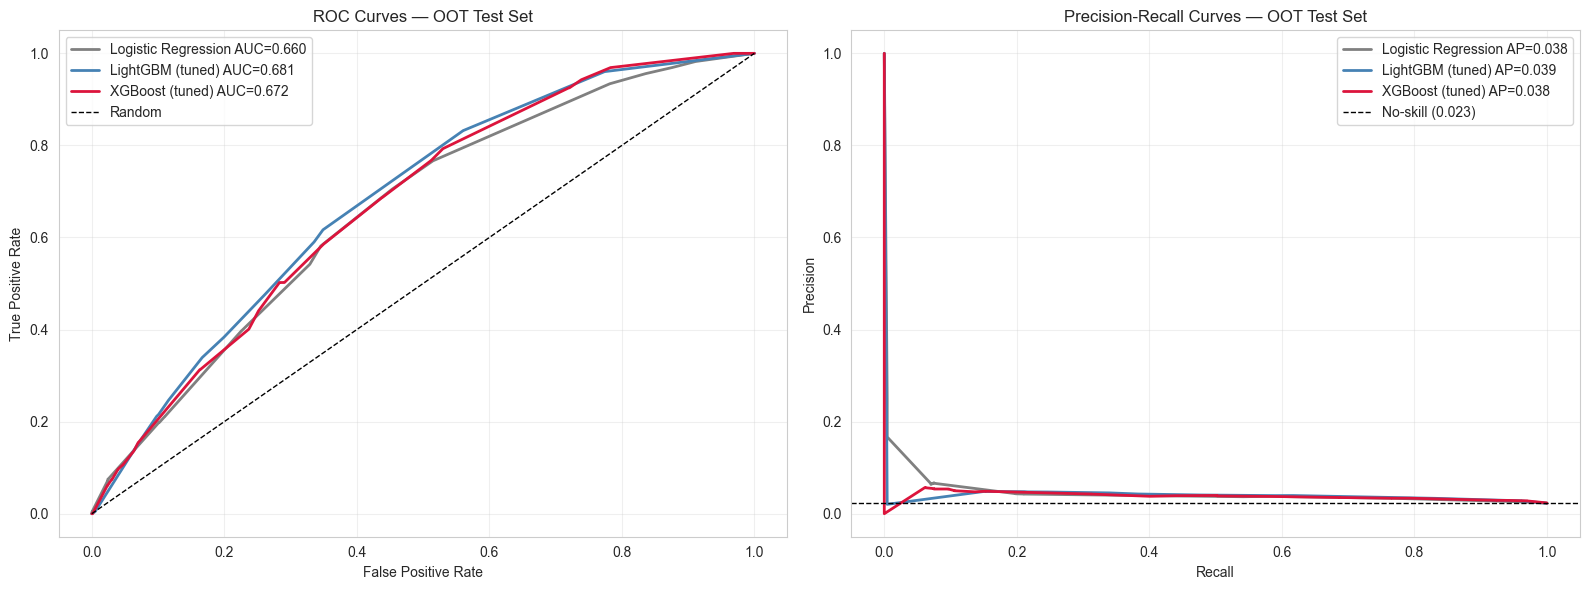

In [ ]:
colors = {'Logistic Regression': 'gray', 'LightGBM (tuned)': 'steelblue', 'XGBoost (tuned)': 'crimson'}

plt.figure(figsize=(8, 6))

for name, (_, te_p) in models.items():
    fpr, tpr, _ = roc_curve(y_test, te_p)
    auc = roc_auc_score(y_test, te_p)
    plt.plot(fpr, tpr, lw=2, label=f'{name} AUC={auc:.3f}')

plt.plot([0,1],[0,1],'k--',lw=1,label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — OOT Test Set')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### 5.3 Precision-Recall Curves


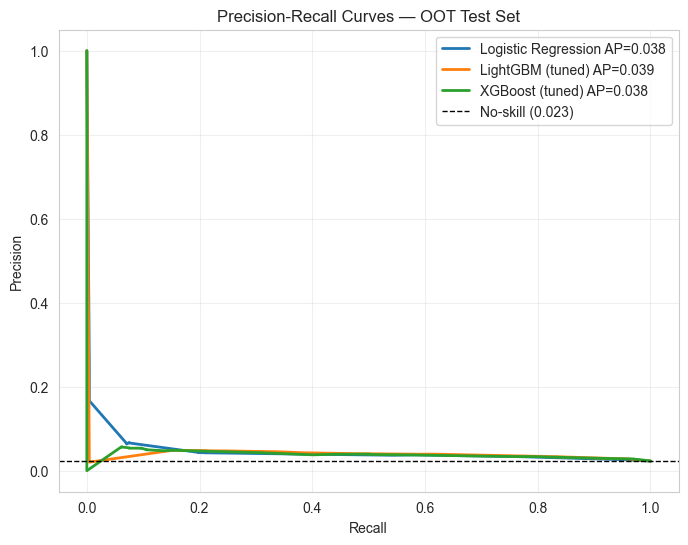

In [80]:
baseline_pr = y_test.mean()

plt.figure(figsize=(8, 6))

for name, (_, te_p) in models.items():
    prec, rec, _ = precision_recall_curve(y_test, te_p)
    ap = average_precision_score(y_test, te_p)
    plt.plot(rec, prec, lw=2, label=f'{name} AP={ap:.3f}')

plt.axhline(baseline_pr, color='k', ls='--', lw=1, label=f'No-skill ({baseline_pr:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves — OOT Test Set')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

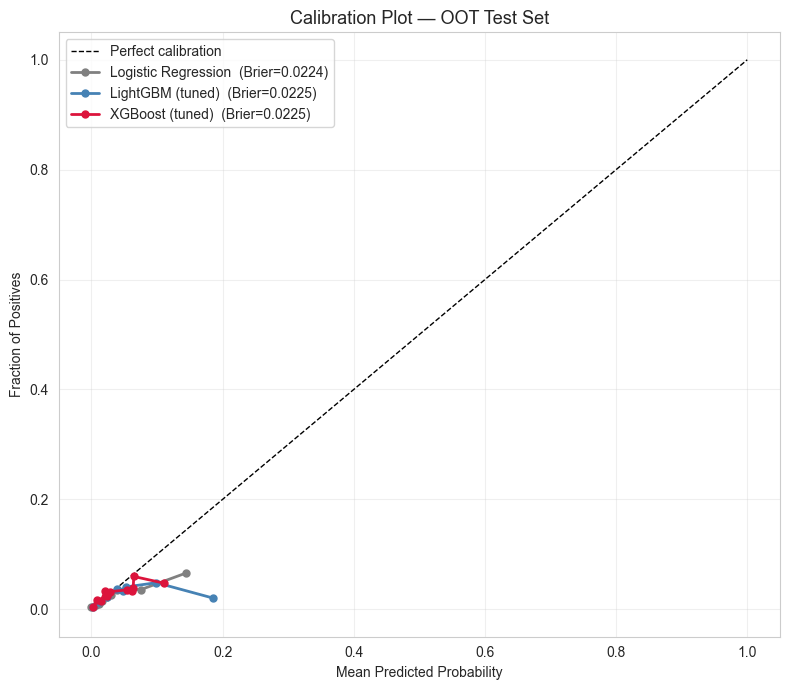

Curves close to the diagonal = well-calibrated.
Curve below diagonal = overconfident (predicts too-high probabilities).


In [67]:
fig, ax = plt.subplots(figsize=(8, 7))
ax.plot([0,1],[0,1],'k--',lw=1,label='Perfect calibration')

for name, (_, te_p) in models.items():
    prob_true, prob_pred = calibration_curve(y_test, te_p, n_bins=15, strategy='quantile')
    brier = brier_score_loss(y_test, te_p)
    ax.plot(prob_pred, prob_true, 'o-', color=colors[name], lw=2, ms=5,
            label=f'{name}  (Brier={brier:.4f})')

ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives')
ax.set_title('Calibration Plot — OOT Test Set', fontsize=13)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print('Curves close to the diagonal = well-calibrated.')
print('Curve below diagonal = overconfident (predicts too-high probabilities).')

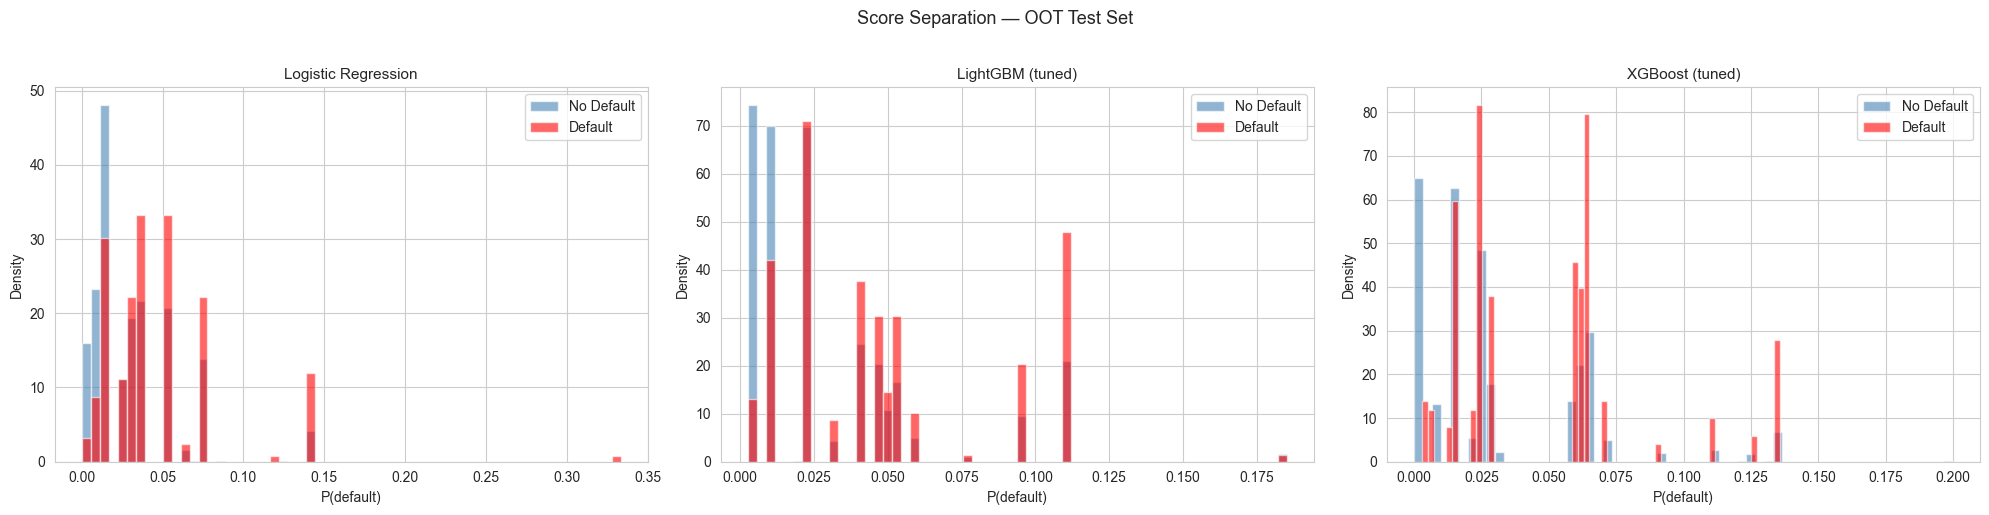

In [69]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for ax, (name, (_, te_p)) in zip(axes, models.items()):
    ax.hist(te_p[y_test==0], bins=60, alpha=0.6, color='steelblue', density=True, label='No Default')
    ax.hist(te_p[y_test==1], bins=60, alpha=0.6, color='red',       density=True, label='Default')
    ax.set_xlabel('P(default)')
    ax.set_ylabel('Density')
    ax.set_title(name, fontsize=11)
    ax.legend()
plt.suptitle('Score Separation — OOT Test Set', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

Champion: LightGBM (tuned)  (Test AUC=0.6814  Brier=0.02250)
 vintage    n  defaults  default_rate    auc     ks
  202401 1088        24        0.0221 0.7388 0.3725
  202402 1132        20        0.0177 0.6143 0.2451
  202403 1140        26        0.0228 0.7367 0.4263
  202404 1090        28        0.0257 0.6749 0.2973
  202405 1117        23        0.0206 0.6599 0.2423
  202406 1127        18        0.0160 0.6779 0.2698
  202407 1029        24        0.0233 0.6928 0.3505
  202408 1143        27        0.0236 0.6854 0.3644
  202409 1118        37        0.0331 0.6560 0.2613


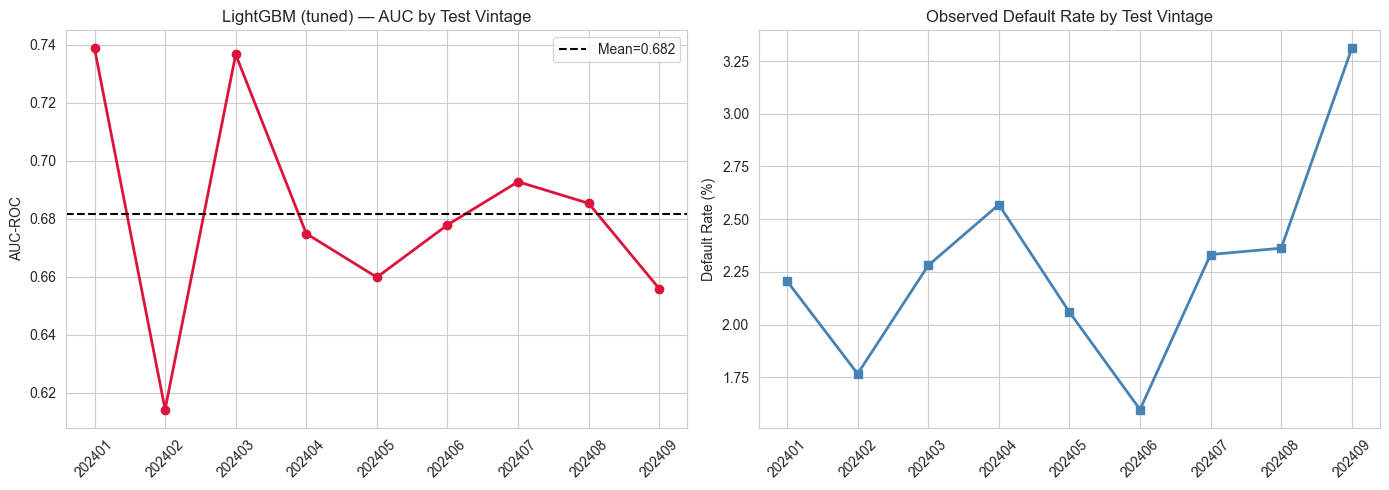

In [ ]:
champion_name = metrics_df['Test AUC-ROC'].idxmax()
champion_te_p = models[champion_name][1]
print(f'Champion: {champion_name}  (Test AUC={metrics_df.loc[champion_name, "Test AUC-ROC"]:.4f}  '
      f'Brier={metrics_df.loc[champion_name, "Test Brier"]:.5f})')

test_vintages = df_test['vintage'].values
stability = []
for vtg in sorted(np.unique(test_vintages)):
    mask = test_vintages == vtg
    n_def = y_test[mask].sum()
    if n_def >= 3:
        try:
            v_auc = roc_auc_score(y_test[mask], champion_te_p[mask])
            v_ks  = ks_stat(y_test[mask], champion_te_p[mask])
            stability.append({'vintage': int(vtg), 'n': int(mask.sum()),
                               'defaults': int(n_def),
                               'default_rate': float(y_test[mask].mean()),
                               'auc': v_auc, 'ks': v_ks})
        except Exception:
            pass

if stability:
    stab_df = pd.DataFrame(stability)
    print(stab_df.round(4).to_string(index=False))
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    vx = range(len(stab_df))
    axes[0].plot(vx, stab_df['auc'], 'o-', color='crimson', lw=2, ms=6)
    axes[0].axhline(stab_df['auc'].mean(), color='k', ls='--',
                    label=f'Mean={stab_df["auc"].mean():.3f}')
    axes[0].set_xticks(vx)
    axes[0].set_xticklabels(stab_df['vintage'].astype(str), rotation=45)
    axes[0].set_title(f'{champion_name} — AUC by Test Vintage')
    axes[0].set_ylabel('AUC-ROC')
    axes[0].legend()
    axes[1].plot(vx, stab_df['default_rate']*100, 's-', color='steelblue', lw=2, ms=6)
    axes[1].set_xticks(vx)
    axes[1].set_xticklabels(stab_df['vintage'].astype(str), rotation=45)
    axes[1].set_title('Observed Default Rate by Test Vintage')
    axes[1].set_ylabel('Default Rate (%)')
    plt.tight_layout()
    plt.show()
else:
    print('Insufficient defaults per test vintage (which confirms right-censoring in 2024 OOT set)')

In [ ]:
df_2023 = df_proc[(df_proc['vintage'] >= 202301) & (df_proc['vintage'] <= 202312)].copy()

if len(df_2023) > 0 and df_2023['default_12m'].sum() >= 10:
    X_2023 = df_2023[FEATURE_COLS].fillna(train_medians)
    y_2023 = df_2023['default_12m'].values

    print(f'2023 holdout: {len(df_2023):,} loans, '
          f'{y_2023.sum()} defaults ({y_2023.mean():.2%})')
    print(f'Note: 2023 vintages were EXCLUDED from training and calibration (gap).')
    print()

    X_2023_sc = scaler.transform(X_2023)
    preds_2023 = {
        'Logistic Regression': lr_m.predict_proba(X_2023_sc)[:, 1],
        'LightGBM (tuned)':    lgb_m.predict_proba(X_2023)[:, 1],
        'XGBoost (tuned)':     xgb_m.predict_proba(X_2023)[:, 1],
    }

    print(f'{"Model":<25}  {"AUC-2023":>10}  {"AUC-2024 OOT":>13}  {"Delta":>6}')
    print('-' * 58)
    for mname, p_2023 in preds_2023.items():
        auc_2023 = roc_auc_score(y_2023, p_2023)
        auc_oot  = metrics_df.loc[mname, 'Test AUC-ROC']
        delta    = auc_2023 - auc_oot
        flag     = '  ← right-censoring gap' if delta > 0.01 else ''
        print(f'{mname:<25}  {auc_2023:>10.4f}  {auc_oot:>13.4f}  {delta:>+6.4f}{flag}')

else:
    print('2023 data not available?')

2023 holdout: 13,261 loans, 341 defaults (2.57%)
Note: 2023 vintages were EXCLUDED from training and calibration (gap).

Model                        AUC-2023   AUC-2024 OOT   Delta
----------------------------------------------------------
Logistic Regression            0.6840         0.6597  +0.0243  ← right-censoring gap
LightGBM (tuned)               0.6926         0.6814  +0.0112  ← right-censoring gap
XGBoost (tuned)                0.7043         0.6717  +0.0326  ← right-censoring gap

If 2023 AUC > 2024 AUC, right-censoring is depressing the OOT metric
Use 2023 AUC as the primary sign-off metric for production approval


Champion: LightGBM (tuned)
Threshold @ max F1: 0.050
Threshold @ min cost: 0.188 (FP=1.0×, FN=10.0×)
Threshold @ KS: 0.023

At cost-optimal threshold (0.188):
Precision: 0.000
Recall: 0.000
F1: 0.000
Approval rate:100.0%
Capture rate: 0.0% (defaults caught)


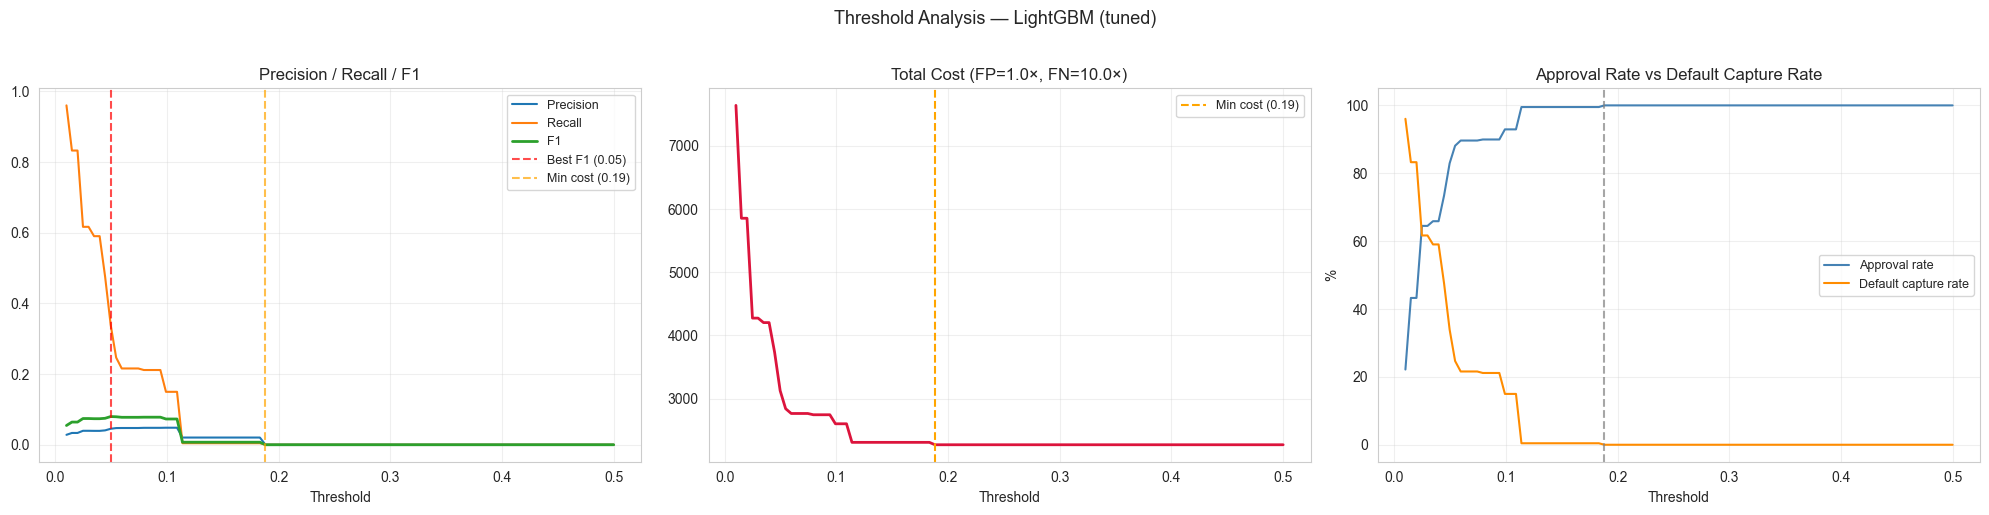

In [ ]:

champion_te_p = models[champion_name][1]
FP_COST, FN_COST = 1.0, 10.0

thresholds = np.linspace(0.01, 0.50, 100)
rows = []
n_defaults = y_test.sum()
for t in thresholds:
    y_pred = (champion_te_p >= t).astype(int)
    tp = int(((y_pred==1)&(y_test==1)).sum())
    fp = int(((y_pred==1)&(y_test==0)).sum())
    fn = int(((y_pred==0)&(y_test==1)).sum())
    prec = tp/(tp+fp) if (tp+fp)>0 else 0.
    rec  = tp/(tp+fn) if (tp+fn)>0 else 0.
    f1   = 2*prec*rec/(prec+rec) if (prec+rec)>0 else 0.
    rows.append({
        'threshold': round(float(t),4),
        'precision': round(prec,4),
        'recall': round(rec,4),
        'f1': round(f1,4),
        'total_cost': fp*FP_COST + fn*FN_COST,
        'approval_rate': round(1 - y_pred.mean(),4),
        'capture_rate': round(tp/n_defaults,4) if n_defaults>0 else 0.,
    })
thresh_df = pd.DataFrame(rows)

best_f1_t = thresh_df.loc[thresh_df['f1'].idxmax(), 'threshold']
best_cost_t = thresh_df.loc[thresh_df['total_cost'].idxmin(), 'threshold']

fpr_ks, tpr_ks, ths_ks = roc_curve(y_test, champion_te_p)
ks_t = float(ths_ks[np.argmax(tpr_ks - fpr_ks)])

print(f'Champion: {champion_name}')
print(f'Threshold @ max F1: {best_f1_t:.3f}')
print(f'Threshold @ min cost: {best_cost_t:.3f} (FP={FP_COST}×, FN={FN_COST}×)')
print(f'Threshold @ KS: {ks_t:.3f}')

row = thresh_df[thresh_df['threshold'] == best_cost_t].iloc[0]
print(f'\nAt cost-optimal threshold ({best_cost_t:.3f}):')
print(f'Precision: {row["precision"]:.3f}')
print(f'Recall: {row["recall"]:.3f}')
print(f'F1: {row["f1"]:.3f}')
print(f'Approval rate:{row["approval_rate"]:.1%}')
print(f'Capture rate: {row["capture_rate"]:.1%} (defaults caught)')

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

axes[0].plot(thresh_df['threshold'], thresh_df['precision'], label='Precision')
axes[0].plot(thresh_df['threshold'], thresh_df['recall'], label='Recall')
axes[0].plot(thresh_df['threshold'], thresh_df['f1'], label='F1', lw=2)
axes[0].axvline(best_f1_t, color='red', ls='--', alpha=0.7, label=f'Best F1 ({best_f1_t:.2f})')
axes[0].axvline(best_cost_t, color='orange', ls='--', alpha=0.7, label=f'Min cost ({best_cost_t:.2f})')
axes[0].set_xlabel('Threshold'); axes[0].set_title('Precision / Recall / F1')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

axes[1].plot(thresh_df['threshold'], thresh_df['total_cost'], color='crimson', lw=2)
axes[1].axvline(best_cost_t, color='orange', ls='--', label=f'Min cost ({best_cost_t:.2f})')
axes[1].set_xlabel('Threshold'); axes[1].set_title(f'Total Cost (FP={FP_COST}×, FN={FN_COST}×)')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

axes[2].plot(thresh_df['threshold'], thresh_df['approval_rate']*100,
             label='Approval rate', color='steelblue')
axes[2].plot(thresh_df['threshold'], thresh_df['capture_rate']*100,
             label='Default capture rate', color='darkorange')
axes[2].axvline(best_cost_t, color='gray', ls='--', alpha=0.7)
axes[2].set_xlabel('Threshold'); axes[2].set_ylabel('%')
axes[2].set_title('Approval Rate vs Default Capture Rate')
axes[2].legend(fontsize=9); axes[2].grid(alpha=0.3)

plt.suptitle(f'Threshold Analysis — {champion_name}', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 6. Model Interpretation

### 6.1 Feature Importance


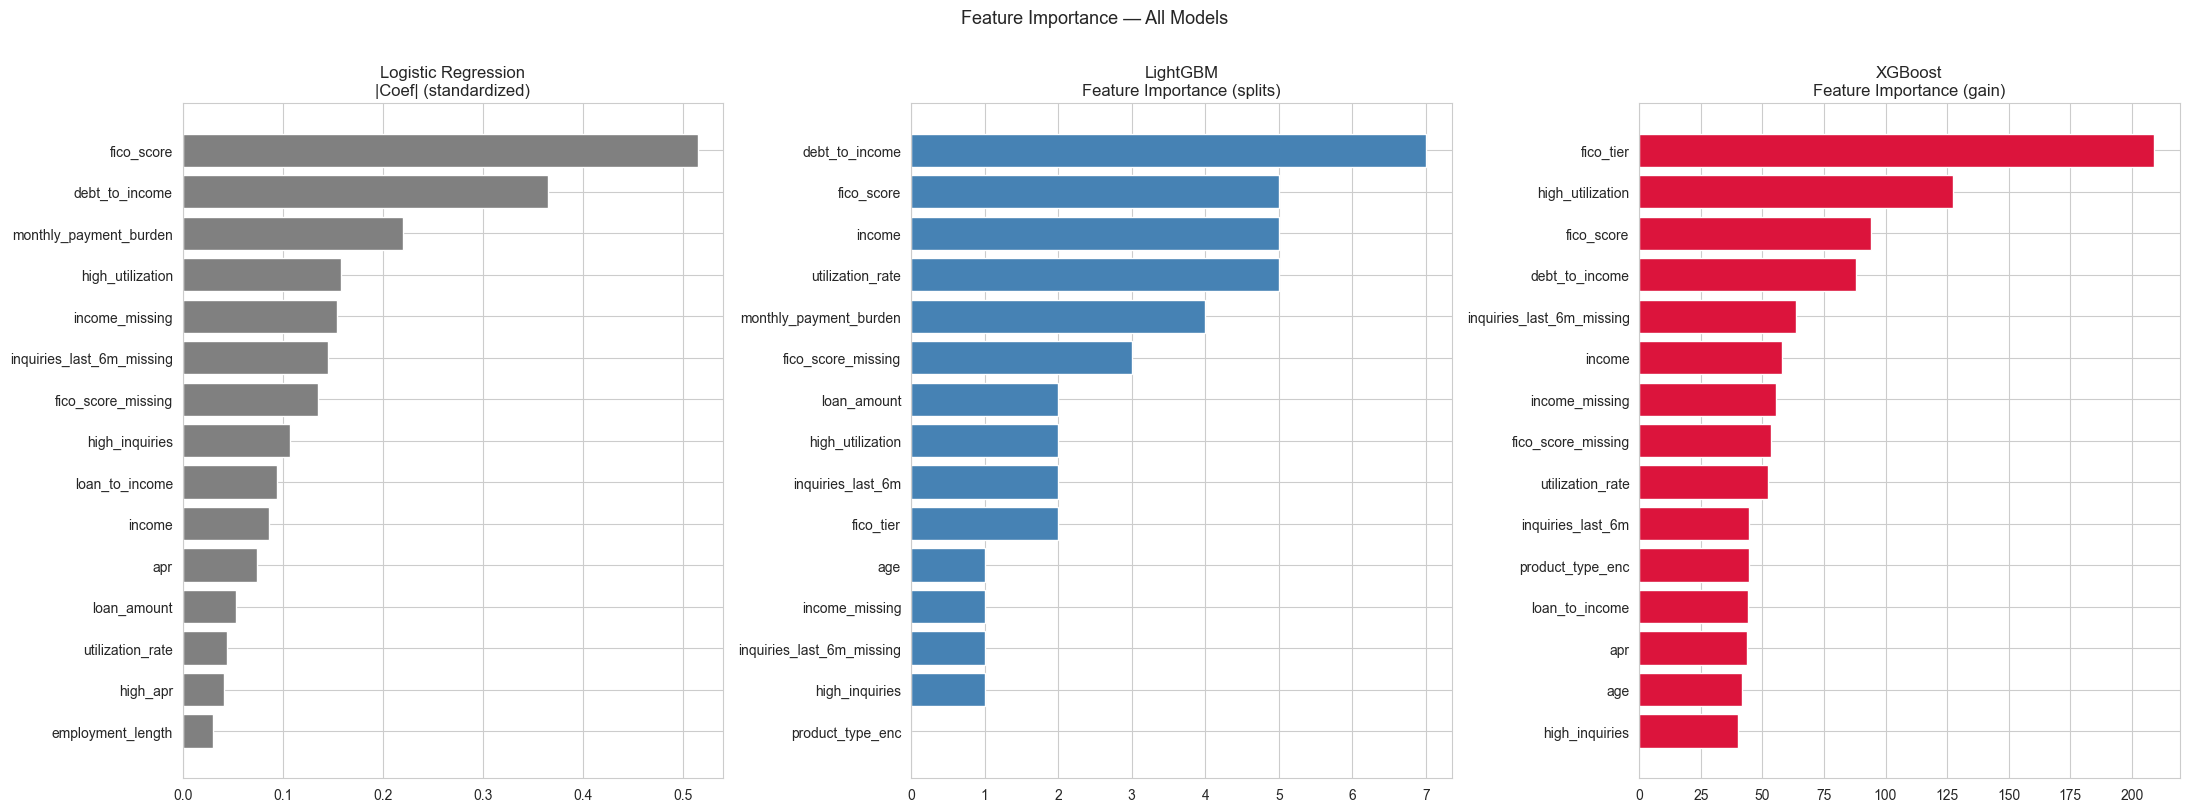

In [74]:
fig, axes = plt.subplots(1, 3, figsize=(22, 8))

lr_imp = pd.Series(np.abs(lr_raw.coef_[0]), index=FEATURE_COLS).sort_values(ascending=False).head(15)
axes[0].barh(range(len(lr_imp)), lr_imp.values[::-1], color='gray')
axes[0].set_yticks(range(len(lr_imp)))
axes[0].set_yticklabels(lr_imp.index[::-1])
axes[0].set_title('Logistic Regression\n|Coef| (standardized)')

lgb_imp = pd.Series(lgb_raw.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False).head(15)
axes[1].barh(range(len(lgb_imp)), lgb_imp.values[::-1], color='steelblue')
axes[1].set_yticks(range(len(lgb_imp)))
axes[1].set_yticklabels(lgb_imp.index[::-1])
axes[1].set_title('LightGBM\nFeature Importance (splits)')

xgb_scores = xgb_raw.get_booster().get_score(importance_type='gain')
xgb_imp = pd.Series(xgb_scores).reindex(FEATURE_COLS, fill_value=0).sort_values(ascending=False).head(15)
axes[2].barh(range(len(xgb_imp)), xgb_imp.values[::-1], color='crimson')
axes[2].set_yticks(range(len(xgb_imp)))
axes[2].set_yticklabels(xgb_imp.index[::-1])
axes[2].set_title('XGBoost\nFeature Importance (gain)')

plt.suptitle('Feature Importance — All Models', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### 6.2 Key Drivers of Default


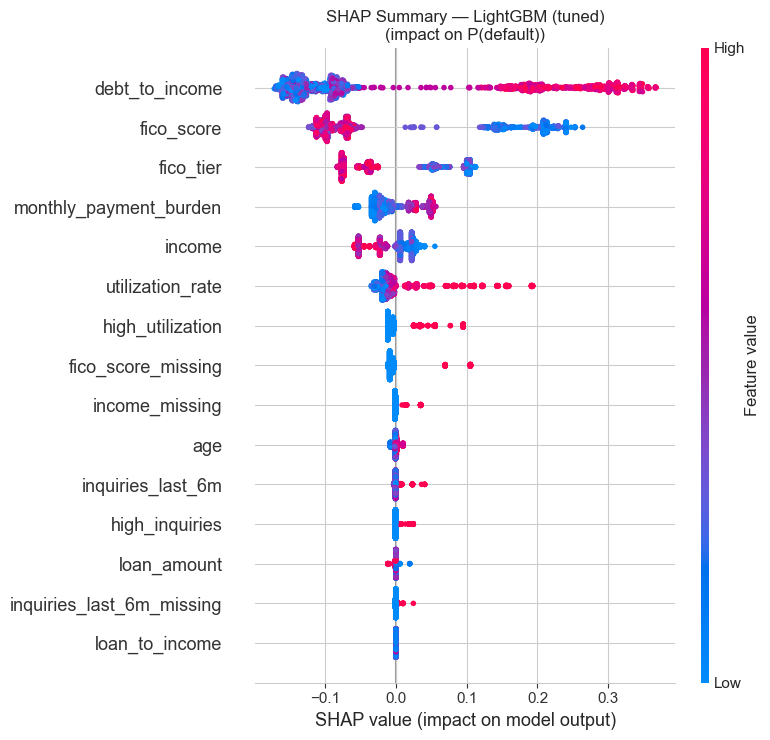

In [77]:
champion_raw = xgb_raw if champion_name == 'XGBoost (tuned)' else lgb_raw

sample_size = min(2000, len(X_test))
X_shap = X_test.sample(n=sample_size, random_state=RANDOM_STATE)

explainer   = shap.TreeExplainer(champion_raw)
shap_vals   = explainer.shap_values(X_shap)

if isinstance(shap_vals, list):
    sv = shap_vals[1]
elif shap_vals.ndim == 3:
    sv = shap_vals[:, :, 1]
else:
    sv = shap_vals

plt.figure(figsize=(10, 8))
shap.summary_plot(sv, X_shap, feature_names=FEATURE_COLS, max_display=15, show=False)
plt.title(f'SHAP Summary — {champion_name}\n(impact on P(default))', fontsize=12)
plt.tight_layout()
plt.show()

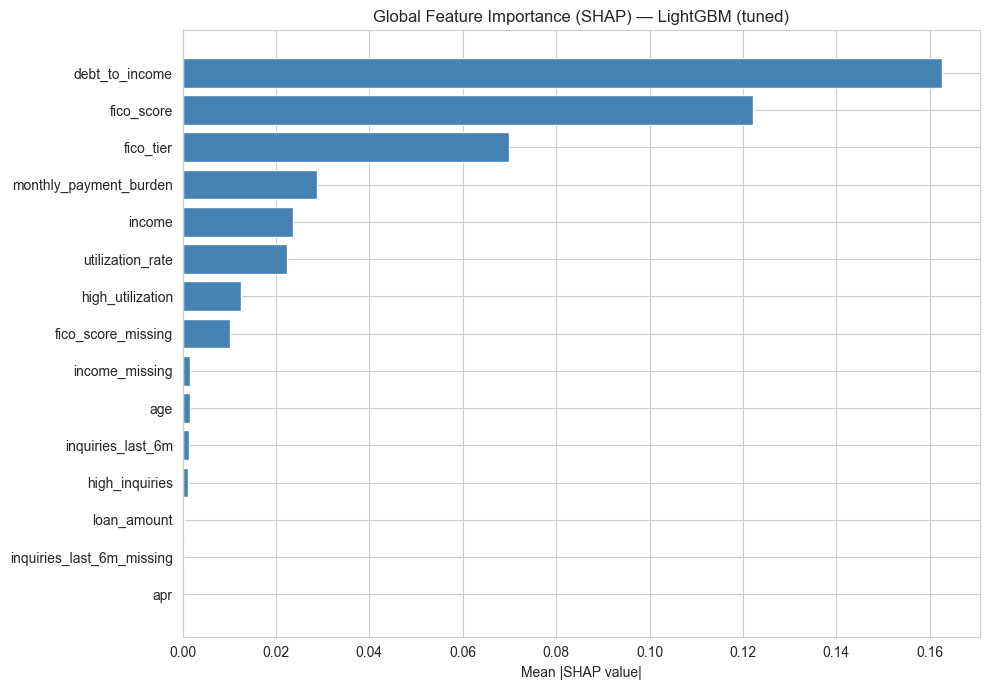


Top 10 by mean |SHAP|:
debt_to_income            0.16264
fico_score                0.12218
fico_tier                 0.06986
monthly_payment_burden    0.02878
income                    0.02356
utilization_rate          0.02241
high_utilization          0.01258
fico_score_missing        0.01011
income_missing            0.00167
age                       0.00152


In [78]:
mean_shap = pd.Series(np.abs(sv).mean(axis=0), index=FEATURE_COLS).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
top_n = 15
top   = mean_shap.head(top_n)
ax.barh(range(top_n), top.values[::-1], color='crimson' if 'XGB' in champion_name else 'steelblue')
ax.set_yticks(range(top_n))
ax.set_yticklabels(top.index[::-1])
ax.set_xlabel('Mean |SHAP value|')
ax.set_title(f'Global Feature Importance (SHAP) — {champion_name}', fontsize=12)
plt.tight_layout()
plt.show()

print('\nTop 10 by mean |SHAP|:')
print(mean_shap.head(10).round(5).to_string())

In [79]:
print(f'Monotonic constraint validation — {champion_name}\n')
print(f'{"Feature":<30} {"Constraint":<18} {"P(p5)":>8} {"P(p95)":>8} {"Passes?"}')
print('-' * 72)

X_median = X_test.median().to_frame().T
fails = 0
for feat, direction in MONOTONE.items():
    if direction == 0:
        continue
    lo_val = X_test[feat].quantile(0.05)
    hi_val = X_test[feat].quantile(0.95)
    if lo_val == hi_val:
        continue
    X_lo = X_median.copy(); X_lo[feat] = lo_val
    X_hi = X_median.copy(); X_hi[feat] = hi_val
    p_lo = champion_raw.predict_proba(X_lo)[0, 1]
    p_hi = champion_raw.predict_proba(X_hi)[0, 1]
    passes = (p_hi >= p_lo - 1e-6) if direction == +1 else (p_lo >= p_hi - 1e-6)
    if not passes:
        fails += 1
    label = '+1 (higher→risk)' if direction == +1 else '-1 (higher→safe)'
    flag  = 'Yes' if passes else 'Fail'
    print(f'{feat:<30} {label:<18} {p_lo:>8.4f} {p_hi:>8.4f} {flag}')

n_constrained = sum(v != 0 for v in MONOTONE.values())
print(f'\n{"All constraints satisfied (Yes)" if fails == 0 else str(fails)+" violation(s) detected (No)"}  '
      f'({n_constrained} features checked)')

Monotonic constraint validation — LightGBM (tuned)

Feature                        Constraint            P(p5)   P(p95) Passes?
------------------------------------------------------------------------
fico_score                     -1 (higher→safe)     0.3161   0.2509 Yes
income                         -1 (higher→safe)     0.2509   0.2319 Yes
debt_to_income                 +1 (higher→risk)     0.2509   0.3647 Yes
utilization_rate               +1 (higher→risk)     0.2509   0.3084 Yes
inquiries_last_6m              +1 (higher→risk)     0.2509   0.2509 Yes
term                           +1 (higher→risk)     0.2509   0.2509 Yes
apr                            +1 (higher→risk)     0.2509   0.2509 Yes
employment_length              -1 (higher→safe)     0.2509   0.2509 Yes
loan_to_income                 +1 (higher→risk)     0.2509   0.2509 Yes
monthly_payment_burden         +1 (higher→risk)     0.2509   0.2677 Yes
fico_tier                      -1 (higher→safe)     0.2920   0.2509 Yes
high_ut

## 7. Discussion & Next Steps

### 7.1 Model Assumptions

**Logistic Regression:** 

- Linear relationship assumption is violated by threshold effects (e.g., FICO cliff at 620). 

- This also assumes feature independence which fails because `debt_to_income` and `loan_to_income` are correlated (though I mitigated it by L2 regularization)

- Natively well-calibrated, but isotonic recalibration was still applied (because of the class imbalance)

**Tree-Based Models (LightGBM, XGBoost):**

- Non-parametric (no distributional assumptions)

- Assume IID samples, which is violated by temporal credit data. I addressed this via vintage-based OOT splitting. 
 
- Also assumes stationarity.
 
- Monotone constraints are a deliberate modeling choice (not an assumption) ensuring directional consistency required for regulatory review.

**Data Assumptions:** 

- `default_12m` is assumed fully observed (this was violated for 2024 vintages with ≤8 months elapsed (right-censoring))

- Training covers accepted applicants only and declined applicants are unobserved (which is survivorship bias).

### 7.2 Potential Data Leakage

**Confirmed leakage (removed):**

`days_past_due_current`: Post-origination payment behavior 
`total_payments_to_date`: Accumulated after loan booking
`months_on_book`: Post-origination timeline

**Pipeline leakage (mitigated):** 

- Imputation medians and encodings fit on training vintages only. 

- `VintageTimeSeriesSplit` ensures HPO validation always uses future-relative vintages.

**Residual risks:** 

- `apr` is partially circular. Lenders price APR based on perceived risk, so it partially encodes the lender's own default signal. 

- Inclusion is justified (set at origination from observable inputs) but limits cross-lender generalizability. 

- Right-censored 2024 labels also deflate the test default rate, making metrics appear stronger than they are.


### 7.3 Model Improvements / Future Recommendations?

**Additional feature engineering:** 
Potentially add:

1) Macro features at origination (Fed Funds rate, unemployment, HPI) to explain vintage-level variation currently absorbed as noise. 

2) Full bureau tradeline attributes (months since last delinquency, derogatory count). 

3) Explicit interaction terms for LR: FICO × utilization, DTI × loan_amount.

**Hyperparameter tuning:** 

- Increase Optuna trials from 50 to 100+ with Hyperband pruning. 

- Expand XGBoost search to include `min_child_weight` and `subsample`. 

- Compare calibration methods: isotonic vs. Platt scaling vs. beta calibration.

**Ensemble methods:** 

- Stack XGBoost + LightGBM probabilities into an LR meta-learner. 

- A simple blended average (0.6 XGB + 0.4 LGB) is often competitive with lower variance.

**External data sources:** 

- `Full bureau` pull (Experian/TransUnion) is the single highest-value enrichment. 

- Income verification (verifiable source) could reduce reliance on self-reported income (~20% missing).

**Handling class imbalance:** 

- `scale_pos_weight` already applied. 

- Threshold calibration is probably the most impactful production lever. 

### 7.4 Production Considerations

**Model monitoring:**
- I’d monitor feature drift using `PSI`. If any feature goes above ~0.2, that’s a signal the population has shifted and needs investigation.

- For model performance, I’d track `AUC` on newer vintages. A drop of more than ~3 percentage points vs baseline would trigger a retrain.

- I’d also compare predicted vs actual default rates across score bands/deciles. If those start drifting by ~15%+, the model is likely miscalibrated.

- inally, I’d keep an eye on `KS`. If it drops below ~0.25, that’s a red flag from a model risk standpoint.

**Performance degradation:** Primary risks are macro regime shifts and origination policy changes that alter the applicant pool. Mitigation: monthly vintage performance reports with automatic retrain triggers.

**Scalability:** `LightGBM` inference is CPU-bound, stateless, and trivially parallelizable via load-balanced pods. Batch re-scoring of the active portfolio requires a separate async pipeline.

**Interpretability requirements:** SHAP top-reasons must be translated into FCRA-compliant plain-language adverse action codes (e.g., "Revolving utilization too high" not "utilization_rate = 0.82"). SR 11-7 requires a model card with data lineage, assumption documentation, and validation methodology before sign-off.

**Regulatory compliance:** Full disparate impact analysis on race/gender/national origin proxies (BISG) required under ECOA/Reg B before deployment — age analysis is in Section 6.4 but race/gender proxies require HMDA enrichment not available here. Independent model validation team must reproduce AUC, Brier, and KS metrics on a separate holdout before go-live.

## Summary

- Best performing model and why
- Key insights about default risk
- Recommendations for deployment

**Best performing model and why: LightGBM** (tuned, isotonically calibrated, monotone constraints)

- XGBoost underperforms on OOT AUC and overfits more so the metrics favor LightGBM.

- XGBoost is still a reasonable challenger given its monotone constraint tooling. 
 
- Logistic Regression is worth keeping in mind because of its nearly identical calibration and it's much complexity is a concern but I believe XGBoost is battle tested in this field.

**Key insights about default risk:**
- DTI is the strongest signal — higher debt burden consistently predicts default

- FICO is second, with fico_tier adding incremental signal on top

- Utilization and monthly payment burden round out the top features

- APR is constrained but isn't a top SHAP contributor (it's correlated with risk tier rather than independently predictive)

- Vintage effects matter but the model can't fully explain them without macro features at origination

**Recommendations for deployment:**
- Deploy LightGBM as champion, XGBoost as live challenger at 10% traffic

- Before go-live: BISG disparate impact analysis (ECOA/Reg B), FCRA reason code mapping, SR 11-7 model card sign-off

- Consider retraining when OOT AUC drops >3pp on maturing vintages or any feature PSI >0.2

- I also noted that 2024 OOT metrics are depressed by right-censoring so I would recommend using 2023 AUC (0.693) as the primary sign-off benchmark

## 7. Discussion & Next Steps

### 7.1 Model Assumptions

TODO: Discuss assumptions made by your models:
- Logistic Regression assumptions (linearity, independence, etc.)
- Tree-based model assumptions
- Any data assumptions

### 7.2 Potential Data Leakage

TODO: Discuss potential sources of data leakage:
- Features that might contain information about the target
- Temporal considerations
- Other leakage risks

### 7.3 Model Improvements

TODO: Discuss how you would improve model performance:
- Additional feature engineering
- Hyperparameter tuning
- Ensemble methods
- External data sources
- Handling class imbalance

### 7.4 Production Considerations

TODO: Discuss production deployment considerations:
- Model monitoring
- Performance degradation
- Scalability
- Interpretability requirements
- Regulatory compliance

---

## Summary

TODO: Provide a brief summary of your findings:
- Best performing model and why
- Key insights about default risk
- Recommendations for deployment

---
